# Random forest

Original MSc coursework, lightly prepared for the portfolio. Retained figures are historical submission outputs, not a fresh run. Missing datasets and methodological limitations are described in [README.md](README.md). Text logs and machine-specific metadata were removed; see the root EDITS.md for code fixes.


Run from this directory in order: `01-preprocessing.ipynb`, `02-feature-engineering.ipynb`, `03-eda.ipynb`, then `04-gradient-boosting.ipynb` and `05-random-forest.ipynb`.

In [20]:
import pandas as pd

In [21]:
X_train = pd.read_csv('data-preprocess/new/X_train.csv')
X_test = pd.read_csv('data-preprocess/new/X_test.csv')
y_train = pd.read_csv('data-preprocess/new/y_train.csv').squeeze()
y_test = pd.read_csv('data-preprocess/new/y_test.csv').squeeze()
X_kaggle = pd.read_csv('data-preprocess/new/X_kaggle.csv')

# Handle NaN values immediately after loading
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)
X_kaggle.fillna(X_kaggle.mean(), inplace=True)

In [22]:
# Chunk 1: Data Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Use the provided datasets
# X_train, X_test, y_train, y_test, X_kaggle are already loaded

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_kaggle_scaled = scaler.transform(X_kaggle)

# Encode target labels
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [23]:
nan_counts = X_train.isna().sum()
print(nan_counts[nan_counts > 0])  # Display only columns with NaN values

In [24]:
# Chunk 2: Train-Test Split and Imbalance Handling
from imblearn.over_sampling import SMOTE

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_encoded)

In [25]:
# Chunk 3: Baseline Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Create and fit the baseline model
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_baseline.fit(X_train_smote, y_train_smote)

# Evaluate the model
y_pred = rf_baseline.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test_encoded, y_pred))
print('F1-score:', f1_score(y_test_encoded, y_pred, average='weighted'))
print('Confusion Matrix:\n', confusion_matrix(y_test_encoded, y_pred))
print('Classification Report:\n', classification_report(y_test_encoded, y_pred))

In [26]:
# Chunk 4: Grid Search with Cross-Validation
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, scoring='f1_weighted', cv=cv, n_jobs=-1
)
grid_search.fit(X_train_smote, y_train_smote)

# Print best parameters and score
print('Best Parameters:', grid_search.best_params_)
print('Best F1-weighted Score:', grid_search.best_score_)

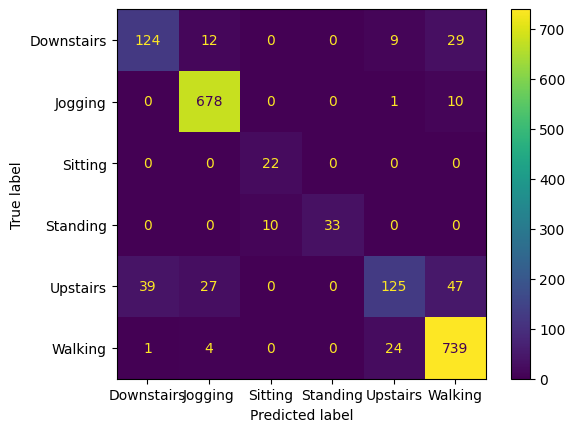

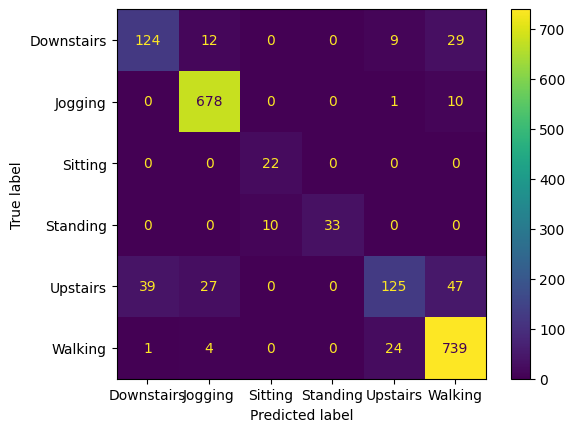

In [27]:
# Chunk 5: Evaluate Tuned Model
from sklearn.metrics import ConfusionMatrixDisplay

# Re-train the best model
best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

# Predict on the test set
y_test_pred = best_model.predict(X_test_scaled)

# Generate evaluation metrics
print('Classification Report:\n', classification_report(y_test_encoded, y_test_pred))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test_encoded, display_labels=encoder.classes_).plot()

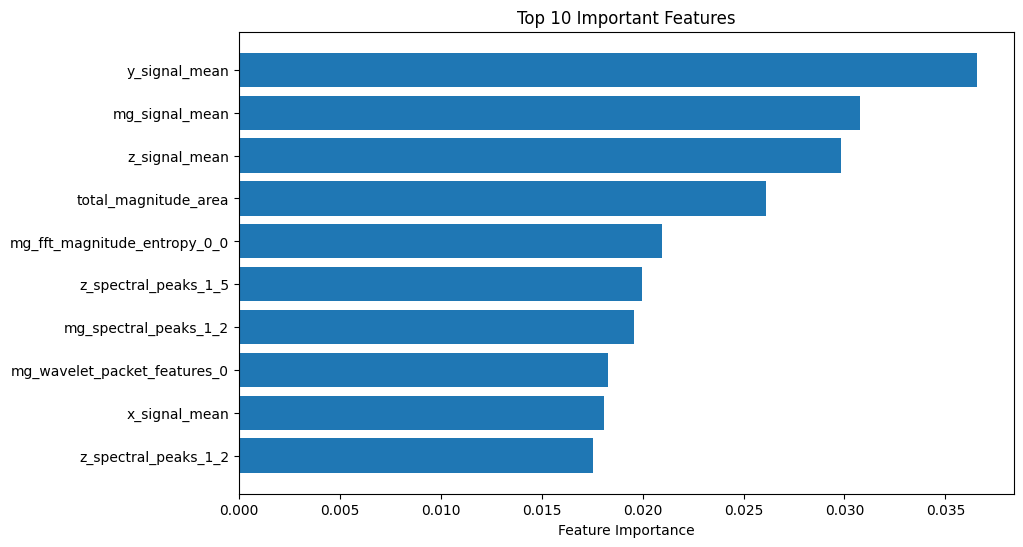

In [ ]:
# Chunk 6: Feature Importance
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]

In [ ]:
from datetime import datetime
import os

# Predict classes
kaggle_pred_int = best_model.predict(X_kaggle_scaled)
kaggle_pred_labels = encoder.inverse_transform(kaggle_pred_int)

# Create CSV (you'll need user_snippet column from original metadata_kaggle.csv)
user_snippet_kaggle = pd.read_csv('data-preprocess/new/user_snippet_kaggle.csv')
submission = pd.DataFrame({
    'user_snippet': user_snippet_kaggle['user_snippet'],
    'prediction': kaggle_pred_labels
})

if not os.path.exists('predictions'):
    os.makedirs('predictions')

current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'predictions/predictions_RandomForest_{current_time}.csv'
submission.to_csv(filename, index=False)

In [30]:
# Automatic Kaggle submission removed for portfolio use. Predictions are saved locally.

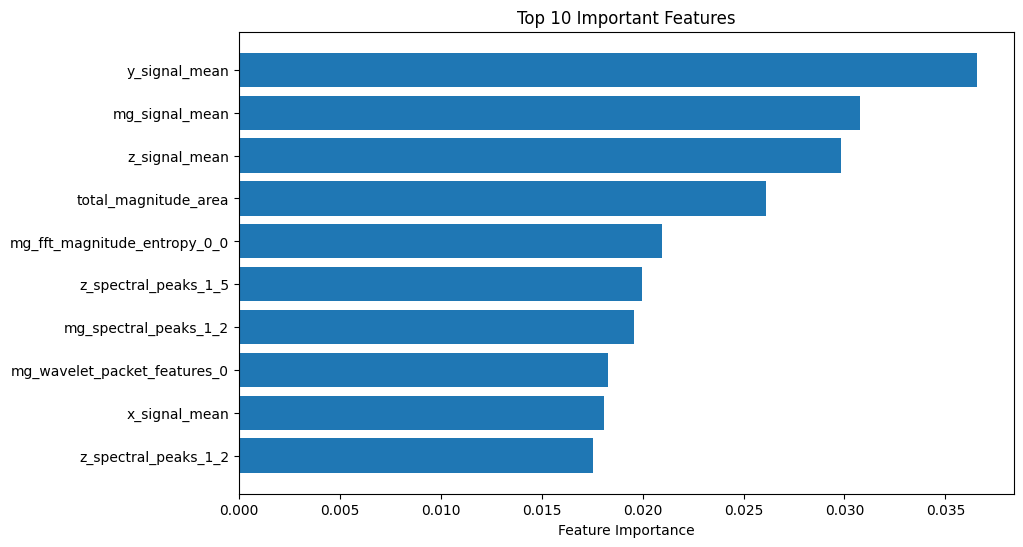

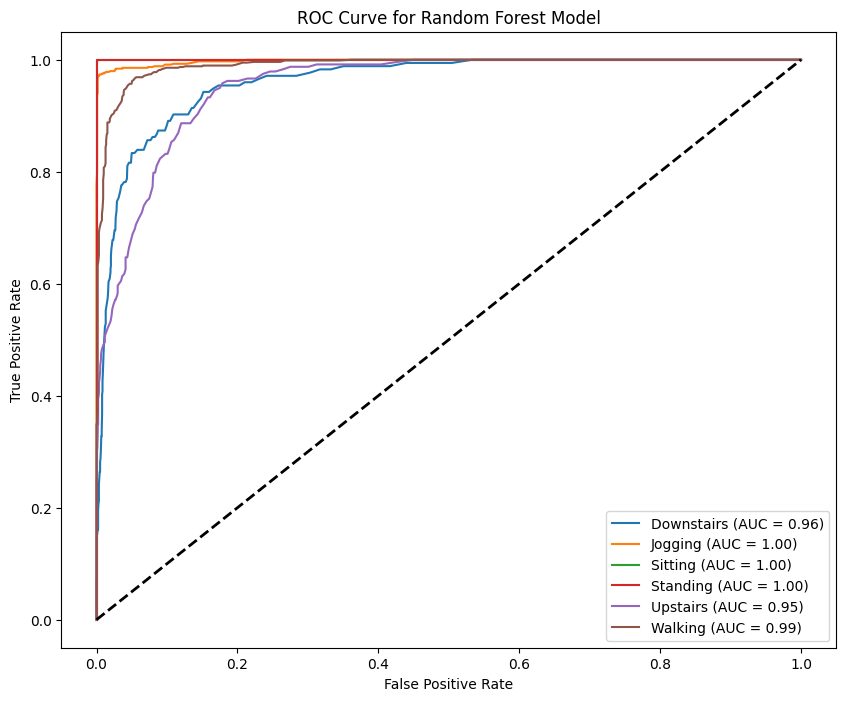

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Features')
plt.show()

# Plot ROC curve for each class
y_test_binarized = label_binarize(y_test_encoded, classes=range(len(encoder.classes_)))
y_test_pred_proba = best_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Model')
plt.legend(loc='lower right')
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions on the training set
y_train_pred = best_model.predict(X_train_smote)

# Metrics for the training set
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
train_precision = precision_score(y_train_smote, y_train_pred, average='weighted')
train_recall = recall_score(y_train_smote, y_train_pred, average='weighted')
train_f1 = f1_score(y_train_smote, y_train_pred, average='weighted')

print("Training Set Metrics:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-score: {train_f1:.4f}")

# Metrics for the test set (already predicted in y_test_pred)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
test_precision = precision_score(y_test_encoded, y_test_pred, average='weighted')
test_recall = recall_score(y_test_encoded, y_test_pred, average='weighted')
test_f1 = f1_score(y_test_encoded, y_test_pred, average='weighted')

print("\nTest Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")